
## 00 Importar librerias

In [65]:
import pandas as pd   #analisis de datos
#import missingno as msno  #visualiza datos nulos
from sklearn.model_selection import train_test_split   #nos permite dividir un dataset en dos bloques, típicamente bloques destinados al entrenamiento y validación del modelo
import matplotlib.pyplot as plt   #visualizar datos, hacer graficos
import seaborn as sns  # graficos
import numpy as np  #calculos numericos
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.feature_selection import SelectKBest, f_regression


## 01 Adjuntar Archivo - Recopilar datos

In [2]:
airbnb= "https://breathecode.herokuapp.com/asset/internal-link?id=927&path=AB_NYC_2019.csv"
data = pd.read_csv(airbnb)
total_data = (data).reset_index(inplace = False)
total_data.drop(columns = ["index"], inplace = True)
total_data.head()

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0


## 02 Exploracion y Limpieza

In [3]:
# Obtener las dimensiones
total_data.shape

(48895, 16)

In [4]:
# Obtener información sobre tipos de datos y valores no nulos
total_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48895 entries, 0 to 48894
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              48895 non-null  int64  
 1   name                            48879 non-null  object 
 2   host_id                         48895 non-null  int64  
 3   host_name                       48874 non-null  object 
 4   neighbourhood_group             48895 non-null  object 
 5   neighbourhood                   48895 non-null  object 
 6   latitude                        48895 non-null  float64
 7   longitude                       48895 non-null  float64
 8   room_type                       48895 non-null  object 
 9   price                           48895 non-null  int64  
 10  minimum_nights                  48895 non-null  int64  
 11  number_of_reviews               48895 non-null  int64  
 12  last_review                     

* Existen un total de 48895 filas (propiedades para alquilar) y 16 columnas, de entre las que encontramos el objetivo a predecir, pudiera ser la variable *price*
* Las variables *last review y reviews_per_month* tienen 38843 instancias con valores, por lo que contendría más de 1000 valores nulos. 
* El resto de variables cuentan siempre con valor.
* Los datos cuentan con 10 características numéricas y 6 características categóricas.

### 2.1 Eliminar duplicados

In [5]:
# Eliminar duplicados 
total_data.drop("host_id", axis = 1).duplicated().sum()

#total_data = total_data.drop_duplicates()  #aplicar si encontramos duplicados.

np.int64(0)

In [6]:
total_data = total_data.drop_duplicates(subset = total_data.columns.difference(["host_id"]))
print(total_data.shape)
total_data.head() # la informacion es igual no hay duplicados.

(48895, 16)


,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0


In [7]:
# Verificar nuevamente si hay duplicados
if total_data.duplicated().sum():
    total_data = total_data.drop_duplicates()
print(total_data.shape)
total_data.head()

(48895, 16)


,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0


### 2.2 Eliminar Informacion Irrelevante

* las variables *id y host_id* son solo números de identificación únicos, No aportan información sobre el precio o características del alojamiento. Son útiles para rastrear registros pero no para predecir.
* las variables *name y host_name* son texto libre, no tienen relacion con algo importante a predecir.
* la variable *last_review* es una fecha específica. Aunque podría indicar qué tan activo está el alojamiento.

### variables importantes:

* neighbourhood_group, neighbourhood: ubicación.
* latitude, longitude: coordenadas geográficas.
* room_type: tipo de habitación.
* price: objetivo a predecir
* minimum_nights: mínimo de noches.
* number_of_reviews: número de reseñas. nuevos o viejos , caros o baratos
* reviews_per_month: frecuencia de reseñas. nuevos o viejos, caros o baratos
* calculated_host_listings_count: cuántos alojamientos tiene el anfitrión, personas o profesionales
* availability_365: días disponibles al año. solo temporada o negocio constante


In [8]:
#eliminar
total_data = total_data.drop(["id", "host_id", "name", "host_name", "last_review"], axis = 1, inplace = False)
#total_data.drop(["id", "host_id", "name", "host_name", "last_review"], axis = 1, inplace = True)
total_data.head()

,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365
0,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,0.21,6,365
1,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,0.38,2,355
2,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,1,365
3,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,4.64,1,194
4,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,0.10,1,0


In [9]:
total_data.info() # nos quedamos con 11 columnas

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48895 entries, 0 to 48894
Data columns (total 11 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   neighbourhood_group             48895 non-null  object 
 1   neighbourhood                   48895 non-null  object 
 2   latitude                        48895 non-null  float64
 3   longitude                       48895 non-null  float64
 4   room_type                       48895 non-null  object 
 5   price                           48895 non-null  int64  
 6   minimum_nights                  48895 non-null  int64  
 7   number_of_reviews               48895 non-null  int64  
 8   reviews_per_month               38843 non-null  float64
 9   calculated_host_listings_count  48895 non-null  int64  
 10  availability_365                48895 non-null  int64  
dtypes: float64(3), int64(5), object(3)
memory usage: 4.1+ MB


## 03 Análisis de variables univariante

Una variable univariante es un término estadístico que se emplea para referenciar un conjunto de observaciones de un atributo. Esto es, el análisis columna a columna del DataFrame. Para ello, debemos distinguir si una variable es categórica o numérica, ya que el cuerpo del análisis y las conclusiones que se pueden obtener serán distintas

### 3.1 Variable categórica

* neighbourhood_group.
* neighbourhood.
* room_type.
* price.
* number_of_reviews.
* availability_365.

se grafican en histogramas

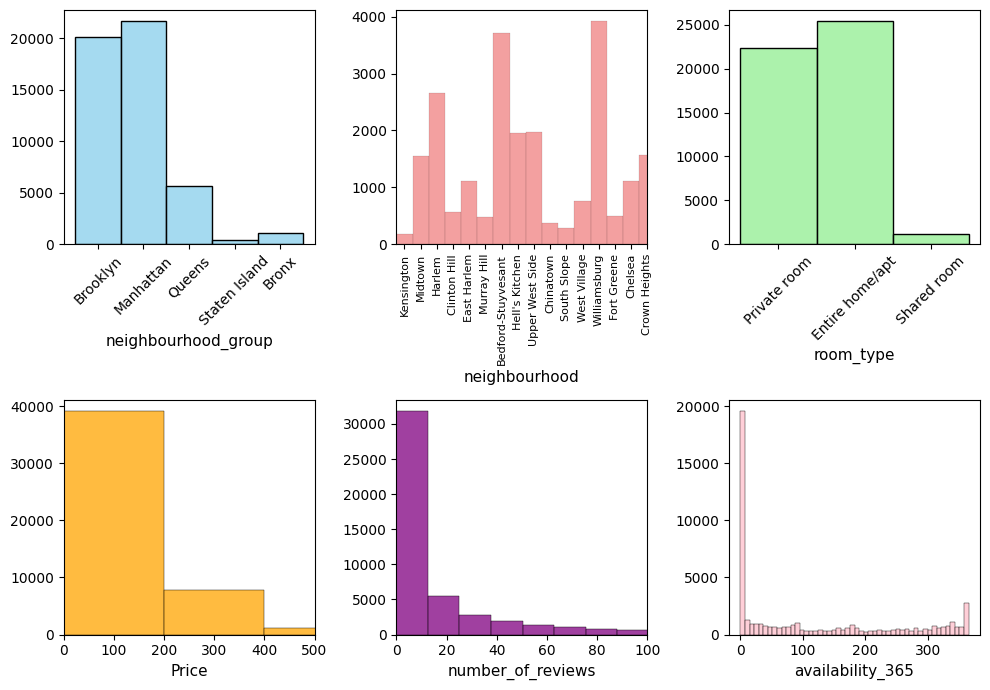

In [10]:
fig, axis = plt.subplots(2, 3, figsize = (10, 7))

# Crear un histograma múltiple
sns.histplot(ax=axis[0, 0], data=total_data, x="neighbourhood_group", color="skyblue").set(ylabel=None)
axis[0, 0].tick_params(axis='x', rotation=45, labelsize=10)
axis[0, 0].set_xlabel("neighbourhood_group", fontsize=11)

sns.histplot(ax=axis[0, 1], data=total_data, x="neighbourhood", color="lightcoral").set(ylabel=None)
axis[0, 1].tick_params(axis='x', rotation=90, labelsize=8)  # Rotación 90° porque hay muchos
axis[0, 1].set_xlabel("neighbourhood", fontsize=11)
axis[0, 1].set_xlim(-0.5, 15)  # Mostrar solo los primeros para legibilidad

sns.histplot(ax=axis[0, 2], data=total_data, x="room_type", color="lightgreen").set(ylabel=None)
axis[0, 2].tick_params(axis='x', rotation=45, labelsize=10)
axis[0, 2].set_xlabel("room_type", fontsize=11)

sns.histplot(ax=axis[1, 0], data=total_data, x="price", bins=50, color="orange").set(ylabel=None)
axis[1, 0].set_xlabel("Price", fontsize=11)
axis[1, 0].set_xlim(0, 500)  # Limitar outliers

sns.histplot(ax=axis[1, 1], data=total_data, x="number_of_reviews", bins=50, color="purple").set(ylabel=None)
axis[1, 1].set_xlabel("number_of_reviews", fontsize=11)
axis[1, 1].set_xlim(0, 100)  # Limitar outliers

sns.histplot(ax=axis[1, 2], data=total_data, x="availability_365", bins=50, color="pink").set(ylabel=None)
axis[1, 2].set_xlabel("availability_365", fontsize=11)
# Ajustar el layout
plt.tight_layout()

# Mostrar el plot
plt.show()

### Conclusiones
#### Neighbourhood_group :
Manhattan y Brooklyn son los que tienen mas alojamientos ya que son los que estan mas cerca de sitios turisticos, Queens tiene un nivel mas bajo y Bronx y Staten Island tienen muy pocos alojamientos.

#### Neighbourhood:
al reducir el numero de vecindarios a mostrar se puede observar que, Williamsburg, Bedford-Stuyvesant, Harlem están en el top de mayor alojamientos, siendo los otros vecindarios menos populares y con una distribución bastante desigual.

#### Room_type:


Entire home/apt,  es el tipo más común de alojamiento, Private room, es el segundo y Shared room es muy poco, la mayoria de los turistas prefieren privacidad.


#### Price: 

La mayoría de precios están entre $0 y $200, teniendo su mayoria entre $50 y $150 y algunos precios demasiado altos.

#### Number_of_reviews:

Los alojamientos tienen pocas reseñas y son pocos los que si tienen, puede ser  que los alojamientos son nuevos o simplemente no gustaron y no dejaron reseña

#### Availability_365:

Hay gran cantidad de alojamientos en el dato 0, lo que nos puede dar a entender que estan disponibles esporadicamente y los que estan disponibles todo el año puede ser por que son profesionales dedicados a este negocio.






### 3.2 Variable numérica

* price
* latitude 
* longitude 
* minimum_nights 
* number_of_reviews 
* calculated_host_listings_count



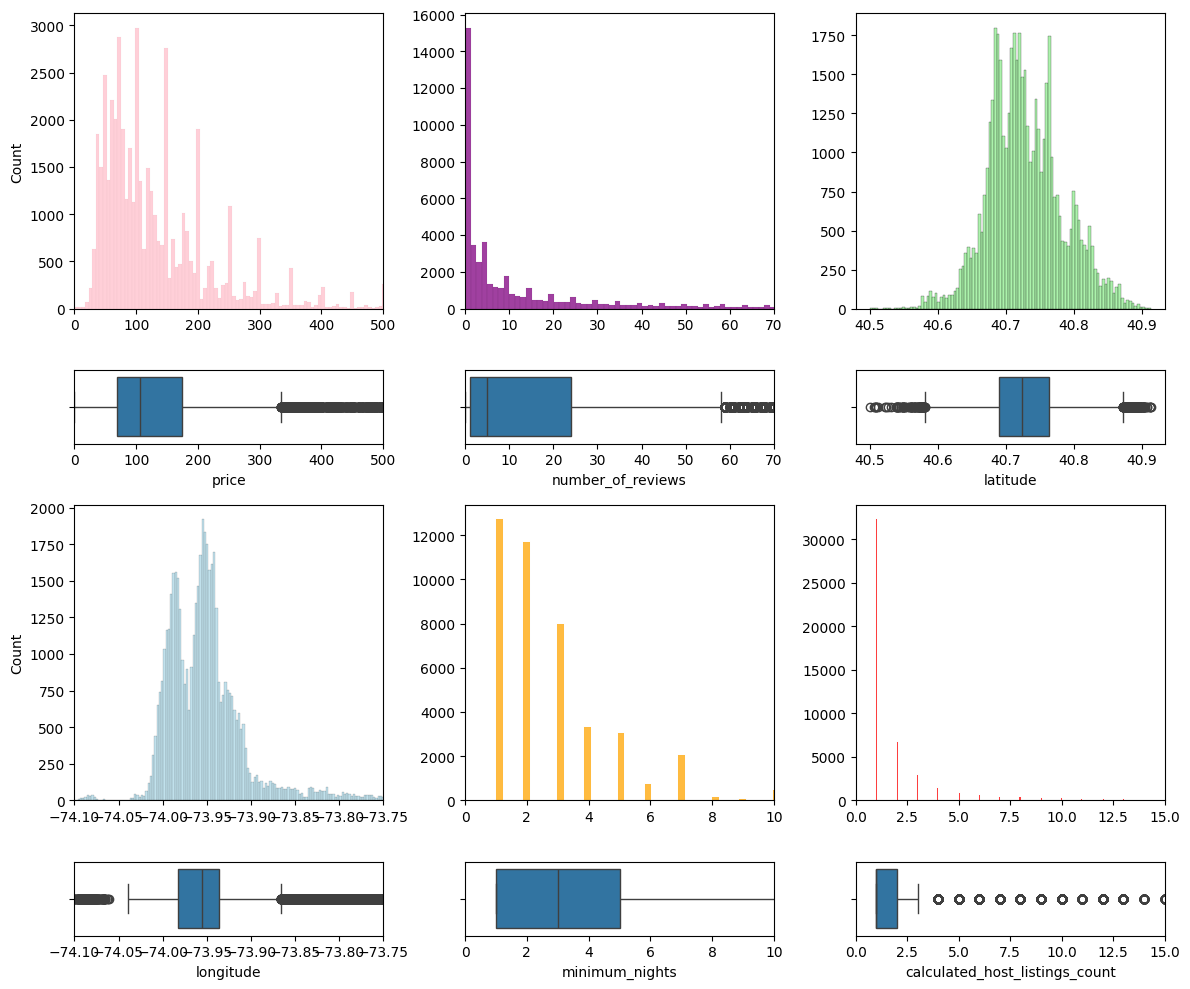

In [11]:


fig, axis = plt.subplots(4, 3, figsize=(12, 10), gridspec_kw={'height_ratios': [4, 1, 4, 1]})

# price
sns.histplot(ax=axis[0, 0], data=total_data, x="price", color= "pink")
axis[0, 0].set_xlim(0, 500)  # Limitar a 0-500 para ver mejor
axis[0, 0].set_xlabel(None)
sns.boxplot(ax=axis[1, 0], data=total_data, x="price")
axis[1, 0].set_xlim(0, 500)  # Limitar a 0-500
axis[1, 0].set_ylabel(None)

# number_of_reviews
sns.histplot(ax=axis[0, 1], data=total_data, x="number_of_reviews", color= "purple")
axis[0, 1].set_xlim(0, 70)  # Limitar a 0-100 para ver mejor
axis[0, 1].set_xlabel(None)
axis[0, 1].set_ylabel(None)
sns.boxplot(ax=axis[1, 1], data=total_data, x="number_of_reviews")
axis[1, 1].set_xlim(0, 70)
axis[1, 1].set_ylabel(None)

# latitude
sns.histplot(ax=axis[0, 2], data=total_data, x="latitude", color= "lightgreen")
axis[0, 2].set_xlabel(None)
axis[0, 2].set_ylabel(None)
sns.boxplot(ax=axis[1, 2], data=total_data, x="latitude")
axis[1, 2].set_ylabel(None)

# longitude
sns.histplot(ax=axis[2, 0], data=total_data, x="longitude", color= "lightblue")
axis[2, 0].set_xlim(-74.1, -73.75)  # Limitar a -74.1 a -73.75 para ver mejor
axis[2, 0].set_xlabel(None)
sns.boxplot(ax=axis[3, 0], data=total_data, x="longitude")
axis[3, 0].set_xlim(-74.1, -73.75)

# minimum_nights - LIMITANDO EL RANGO
sns.histplot(ax=axis[2, 1], data=total_data, x="minimum_nights", color= "orange")
axis[2, 1].set_xlim(0, 10)  # Limitar a 0-10 para ver mejor
axis[2, 1].set_xlabel(None)
axis[2, 1].set_ylabel(None)
sns.boxplot(ax=axis[3, 1], data=total_data, x="minimum_nights")
axis[3, 1].set_xlim(0, 10)  # Limitar a 0-10
axis[3, 1].set_ylabel(None)

# calculated_host_listings_count - LIMITANDO EL RANGO
sns.histplot(ax=axis[2, 2], data=total_data, x="calculated_host_listings_count", color= "red")
axis[2, 2].set_xlim(0, 15)  # Limitar a 0-15 para ver mejor
axis[2, 2].set_xlabel(None)
axis[2, 2].set_ylabel(None)
sns.boxplot(ax=axis[3, 2], data=total_data, x="calculated_host_listings_count")
axis[3, 2].set_xlim(0, 15)  # Limitar a 0-15
axis[3, 2].set_ylabel(None)

plt.tight_layout()
plt.show()

## 04 Análisis de variables multivariante

### 4.1 Analisis variable numerica - numerica

utilizaremos las variables 01 Price, 02 number_of_reviews y 03 calculated_host_listings_count, para realizar el analisis de correlacion

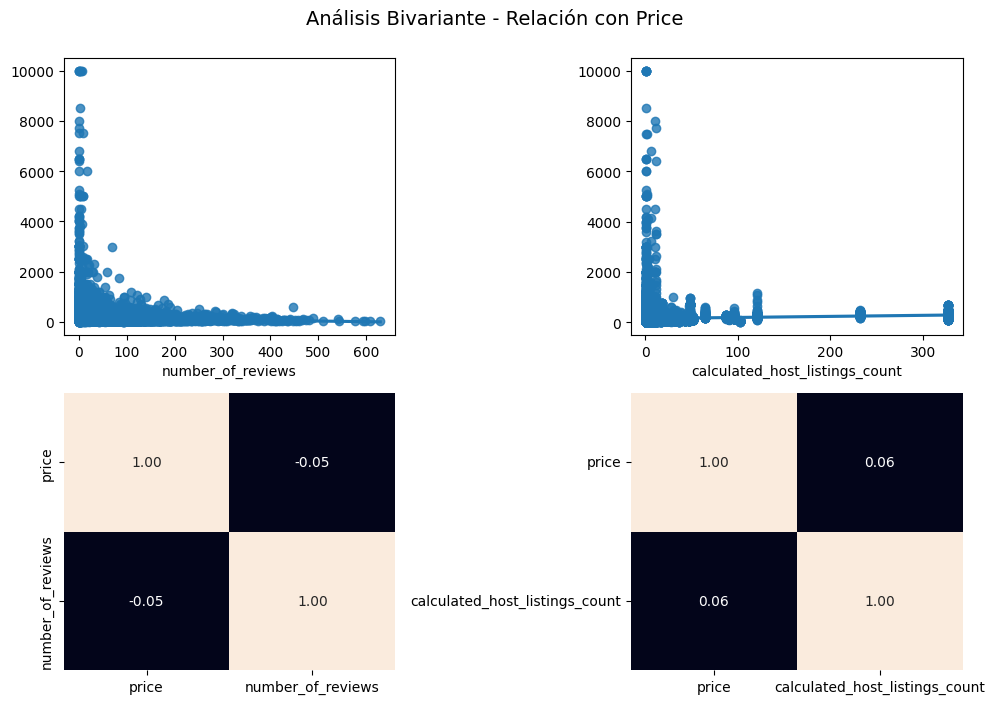

In [12]:
fig, axis = plt.subplots(2, 2, figsize = (10, 7))

# Crear un diagrama de dispersión múltiple
sns.regplot(ax = axis[0, 0], data = total_data, x = "number_of_reviews", y = "price").set(ylabel=None)
sns.heatmap(total_data[["price", "number_of_reviews"]].corr(), annot = True, fmt = ".2f", ax = axis[1, 0], cbar = False)
sns.regplot(ax = axis[0, 1], data = total_data, x = "calculated_host_listings_count", y = "price").set(ylabel=None)
sns.heatmap(total_data[["price", "calculated_host_listings_count"]].corr(), annot = True, fmt = ".2f", ax = axis[1, 1], cbar = False)

# Título general
fig.suptitle('Análisis Bivariante - Relación con Price', fontsize=14, y=1.00)

# Ajustar el layout
plt.tight_layout()

# Mostrar el plot
plt.show()

Conclusiones:
1. Price vs Number of Reviews
Diagrama de Dispersión:

Correlación negativa débil (aproximadamente -0.05 a -0.10)
La mayoría de puntos se concentran en la esquina inferior izquierda (precios bajos, pocas reseñas)
Hay una nube dispersa sin patrón lineal claro

Heatmap de Correlación:

Valor cercano a -0.05 o -0.10
Correlación muy débil/casi inexistente

* Las propiedades más caras tienden a tener MENOS reseñas (correlación negativa)

Posibles razones:

Propiedades caras se reservan menos frecuentemente
Son más exclusivas y tienen menos rotación de huéspedes
Menor accesibilidad = menos clientes = menos reseñas

* Las propiedades baratas tienen MÁS reseñas

Mayor rotación de huéspedes
Más accesibles = más reservas = más reseñas

2. Price vs Calculated Host Listings Count
Diagrama de Dispersión:

Correlación positiva débil (aproximadamente +0.05 a +0.15)
Mayoría de hosts tienen 1-5 propiedades
Algunos outliers con 50+ propiedades

Heatmap de Correlación:

Valor cercano a +0.07 o +0.12
Correlación débil pero positiva

Conclusiones:
* Hosts con MÁS propiedades tienden a cobrar precios LIGERAMENTE más altos

Son hosts profesionales/empresas que optimizan precios
Mejor gestión y conocimiento del mercado
Propiedades mejor equipadas/ubicadas

* Hosts individuales (1-2 propiedades) tienen precios más variables

Menos experiencia 
Pueden subestimar el valor



### 4.2 Analisis variable categórica - categórica

* neighbourhood_group
* room_type 
* neighbourhood

relacion con la variante price

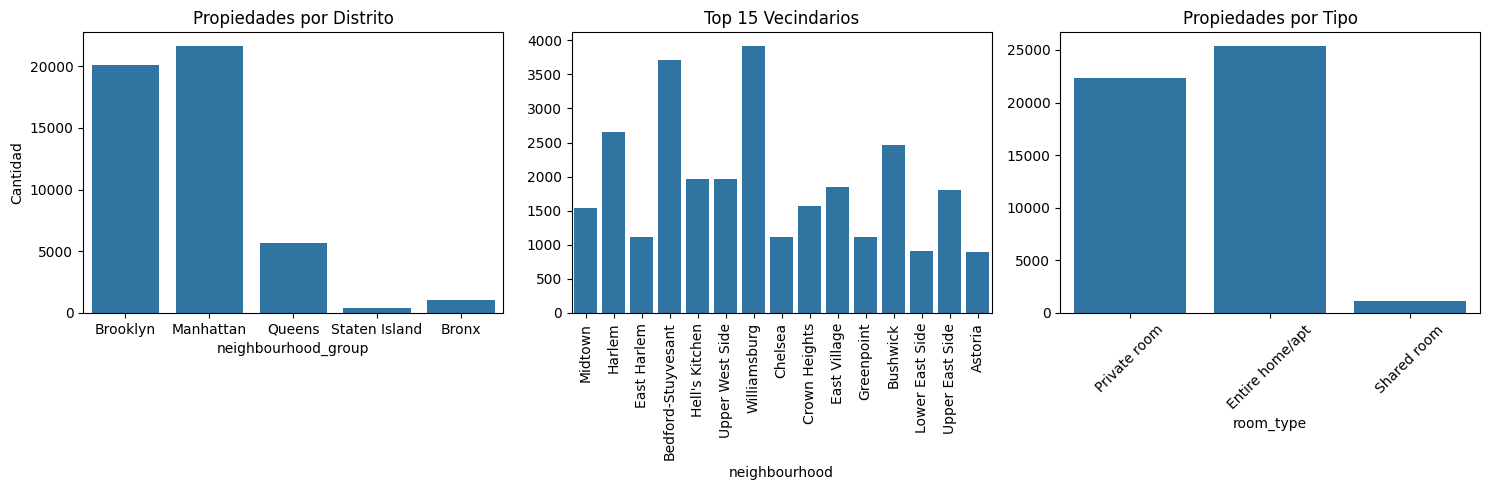

In [13]:
fig, axis = plt.subplots(1, 3, figsize=(15, 5))

# Countplot sin hue
sns.countplot(ax=axis[0], data=total_data, x="neighbourhood_group")
axis[0].set_title('Propiedades por Distrito')
axis[0].set_ylabel('Cantidad')

# neighbourhood - solo top 15
top_neighbourhoods = total_data['neighbourhood'].value_counts().head(15).index
data_filtered = total_data[total_data['neighbourhood'].isin(top_neighbourhoods)]
sns.countplot(ax=axis[1], data=data_filtered, x="neighbourhood")
axis[1].set_title('Top 15 Vecindarios')
axis[1].set_ylabel('')
axis[1].tick_params(axis='x', rotation=90)

sns.countplot(ax=axis[2], data=total_data, x="room_type")
axis[2].set_title('Propiedades por Tipo')
axis[2].set_ylabel('')
axis[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

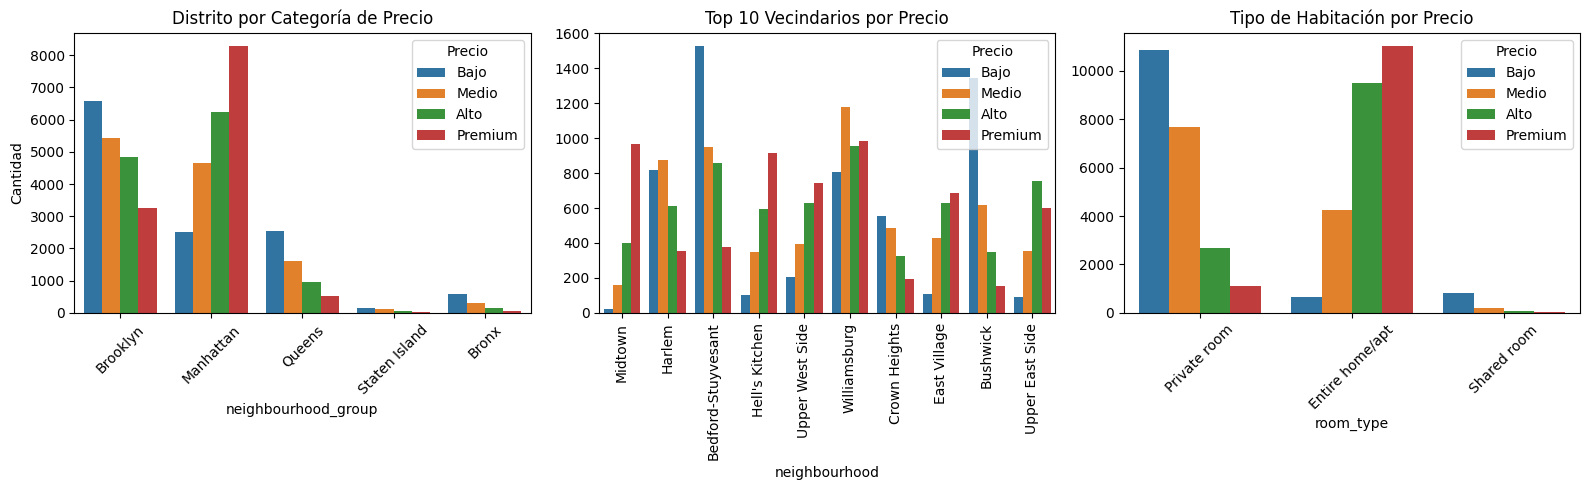

In [14]:
# Crear categoría de precio
total_data['price_category'] = pd.cut(total_data['price'], bins=[0, 69, 106, 175, 10000],  labels=['Bajo', 'Medio', 'Alto', 'Premium'])

fig, axis = plt.subplots(1, 3, figsize=(16, 5))

# neighbourhood_group con categoría de precio
sns.countplot(ax=axis[0], data=total_data, x="neighbourhood_group", hue="price_category")
axis[0].set_title('Distrito por Categoría de Precio')
axis[0].set_ylabel('Cantidad')
axis[0].tick_params(axis='x', rotation=45)
axis[0].legend(title='Precio')

# Top 10 neighbourhoods
top_10 = total_data['neighbourhood'].value_counts().head(10).index
data_top10 = total_data[total_data['neighbourhood'].isin(top_10)]
sns.countplot(ax=axis[1], data=data_top10, x="neighbourhood", hue="price_category")
axis[1].set_title('Top 10 Vecindarios por Precio')
axis[1].set_ylabel('')
axis[1].tick_params(axis='x', rotation=90)
axis[1].legend(title='Precio')

# room_type con categoría de precio
sns.countplot(ax=axis[2], data=total_data, x="room_type", hue="price_category")
axis[2].set_title('Tipo de Habitación por Precio')
axis[2].set_ylabel('')
axis[2].tick_params(axis='x', rotation=45)
axis[2].legend(title='Precio')

plt.tight_layout()
plt.show()

### 4.3 Combinaciones de la clase con varias predictoras

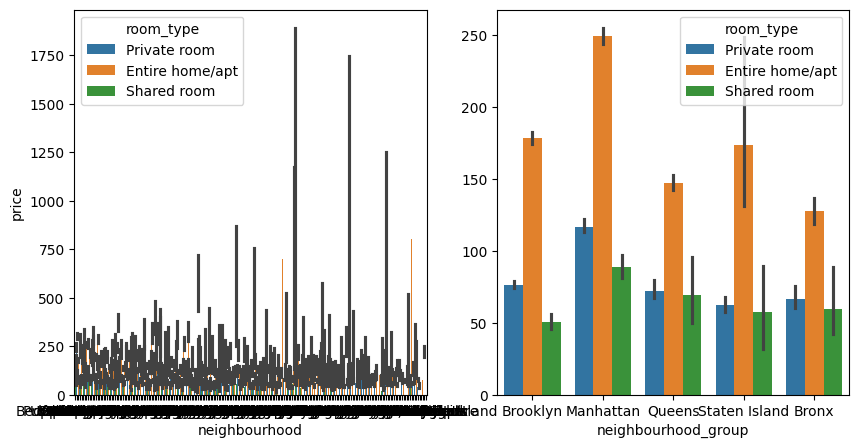

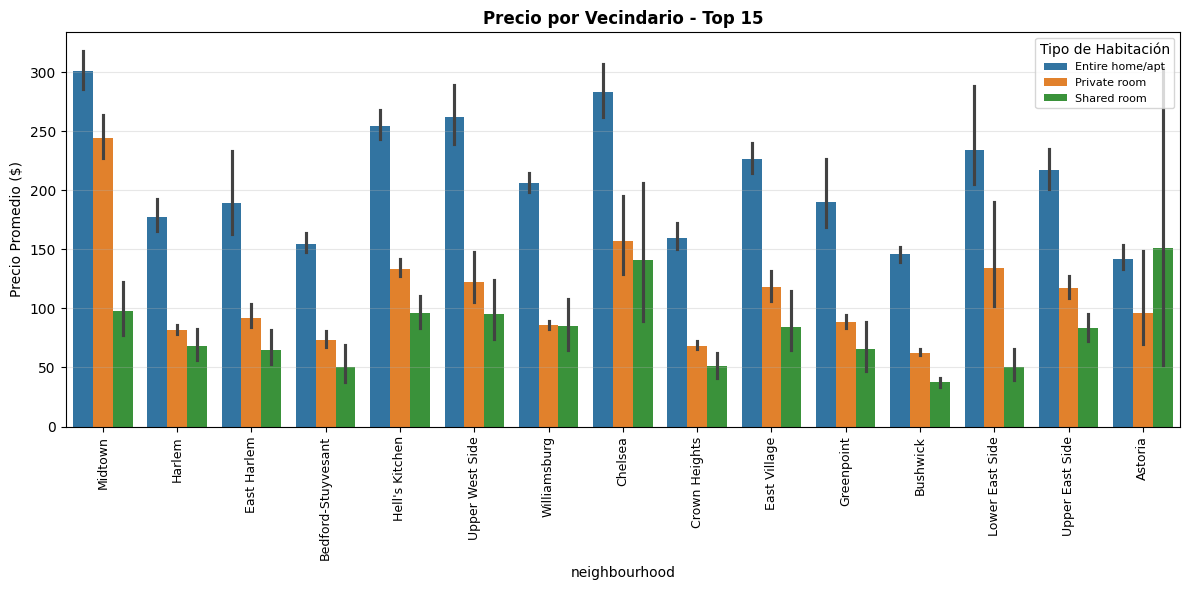

In [15]:
fig, axis = plt.subplots(figsize = (10, 5), ncols = 2)

sns.barplot(ax = axis[0], data = total_data, x = "neighbourhood", y = "price", hue = "room_type")
sns.barplot(ax = axis[1], data = total_data, x = "neighbourhood_group", y = "price", hue = "room_type").set(ylabel = None)


top_15 = total_data['neighbourhood'].value_counts().head(15).index
data_top15 = total_data[total_data['neighbourhood'].isin(top_15)]


fig, axis = plt.subplots(figsize=(12, 6))


sns.barplot(ax=axis, data=data_top15, x="neighbourhood", y="price", hue="room_type")
axis.tick_params(axis='x', rotation=90, labelsize=9)
axis.set_title('Precio por Vecindario - Top 15', fontsize=12, fontweight='bold')
axis.set_xlabel('neighbourhood', fontsize=10)
axis.set_ylabel('Precio Promedio ($)', fontsize=10)
axis.legend(title='Tipo de Habitación', fontsize=8)
axis.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()



Los Top 15 vecindarios concentran una gran parte de toda la oferta
Brooklyn y Manhattan dominan la oferta (especialmente Williamsburg, Harlem, Bushwick)
Hay clara segregación por precio entre vecindarios, y evidentemente el tipo de habitacion mas caro es entire/home apto


### 4.4 Análisis numérico-categórico (completo)


In [16]:
total_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48895 entries, 0 to 48894
Data columns (total 12 columns):
 #   Column                          Non-Null Count  Dtype   
---  ------                          --------------  -----   
 0   neighbourhood_group             48895 non-null  object  
 1   neighbourhood                   48895 non-null  object  
 2   latitude                        48895 non-null  float64 
 3   longitude                       48895 non-null  float64 
 4   room_type                       48895 non-null  object  
 5   price                           48895 non-null  int64   
 6   minimum_nights                  48895 non-null  int64   
 7   number_of_reviews               48895 non-null  int64   
 8   reviews_per_month               38843 non-null  float64 
 9   calculated_host_listings_count  48895 non-null  int64   
 10  availability_365                48895 non-null  int64   
 11  price_category                  48884 non-null  category
dtypes: category(1), fl

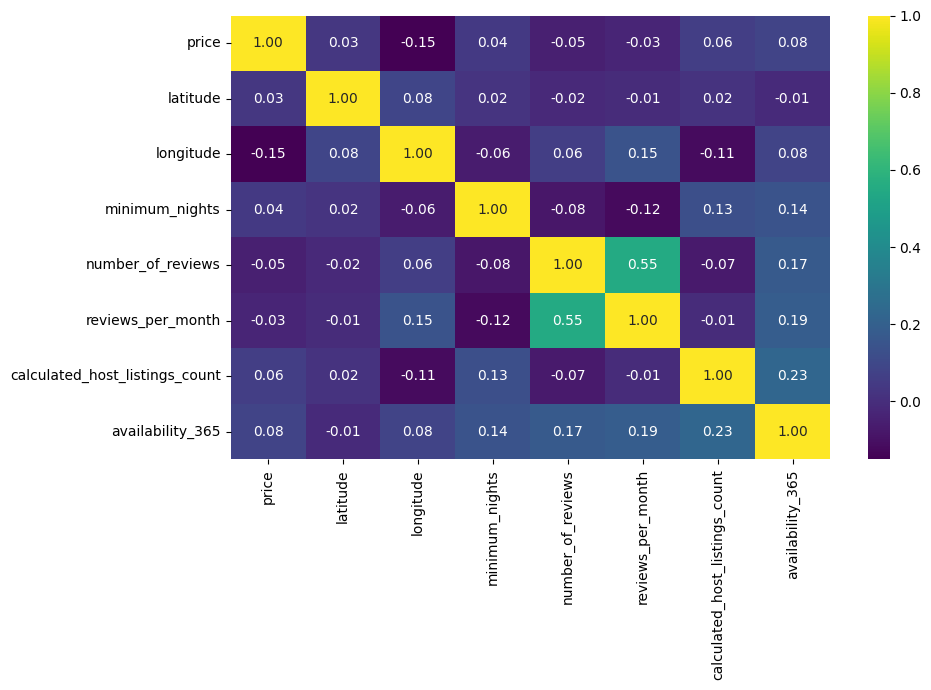

In [17]:
cols_num = ["price", "latitude", "longitude", "minimum_nights", "number_of_reviews", "reviews_per_month", "calculated_host_listings_count","availability_365"]  # todas numéricas
fig, ax = plt.subplots(figsize=(10,7))
sns.heatmap(total_data[cols_num].corr(method="pearson"), annot=True, fmt=".2f", cmap="viridis", ax=ax)
plt.tight_layout()
plt.show()

la grafica de correlación muestra que las variables numericas tienen relaciones mayormente débiles entre sí, lo que sugiere que el precio está influenciado principalmente por variables 
categóricas como neighbourhood, room_type, y availability. 

Las únicas correlaciones moderadas-fuertes se encuentran entre variablesrelacionadas con la actividad de reseñas, confirmando que las propiedades populares mantienen consistencia en su demanda.


In [18]:
total_data[cols_num].corr()


,price,latitude,longitude,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365
price,1.000000,0.033939,-0.150019,0.042799,-0.047954,-0.030608,0.057472,0.081829
latitude,0.033939,1.000000,0.084788,0.024869,-0.015389,-0.010142,0.019517,-0.010983
longitude,-0.150019,0.084788,1.000000,-0.062747,0.059094,0.145948,-0.114713,0.082731
minimum_nights,0.042799,0.024869,-0.062747,1.000000,-0.080116,-0.121702,0.127960,0.144303
number_of_reviews,-0.047954,-0.015389,0.059094,-0.080116,1.000000,0.549868,-0.072376,0.172028
reviews_per_month,-0.030608,-0.010142,0.145948,-0.121702,0.549868,1.000000,-0.009421,0.185791
calculated_host_listings_count,0.057472,0.019517,-0.114713,0.127960,-0.072376,-0.009421,1.000000,0.225701
availability_365,0.081829,-0.010983,0.082731,0.144303,0.172028,0.185791,0.225701,1.000000


### todas las variables

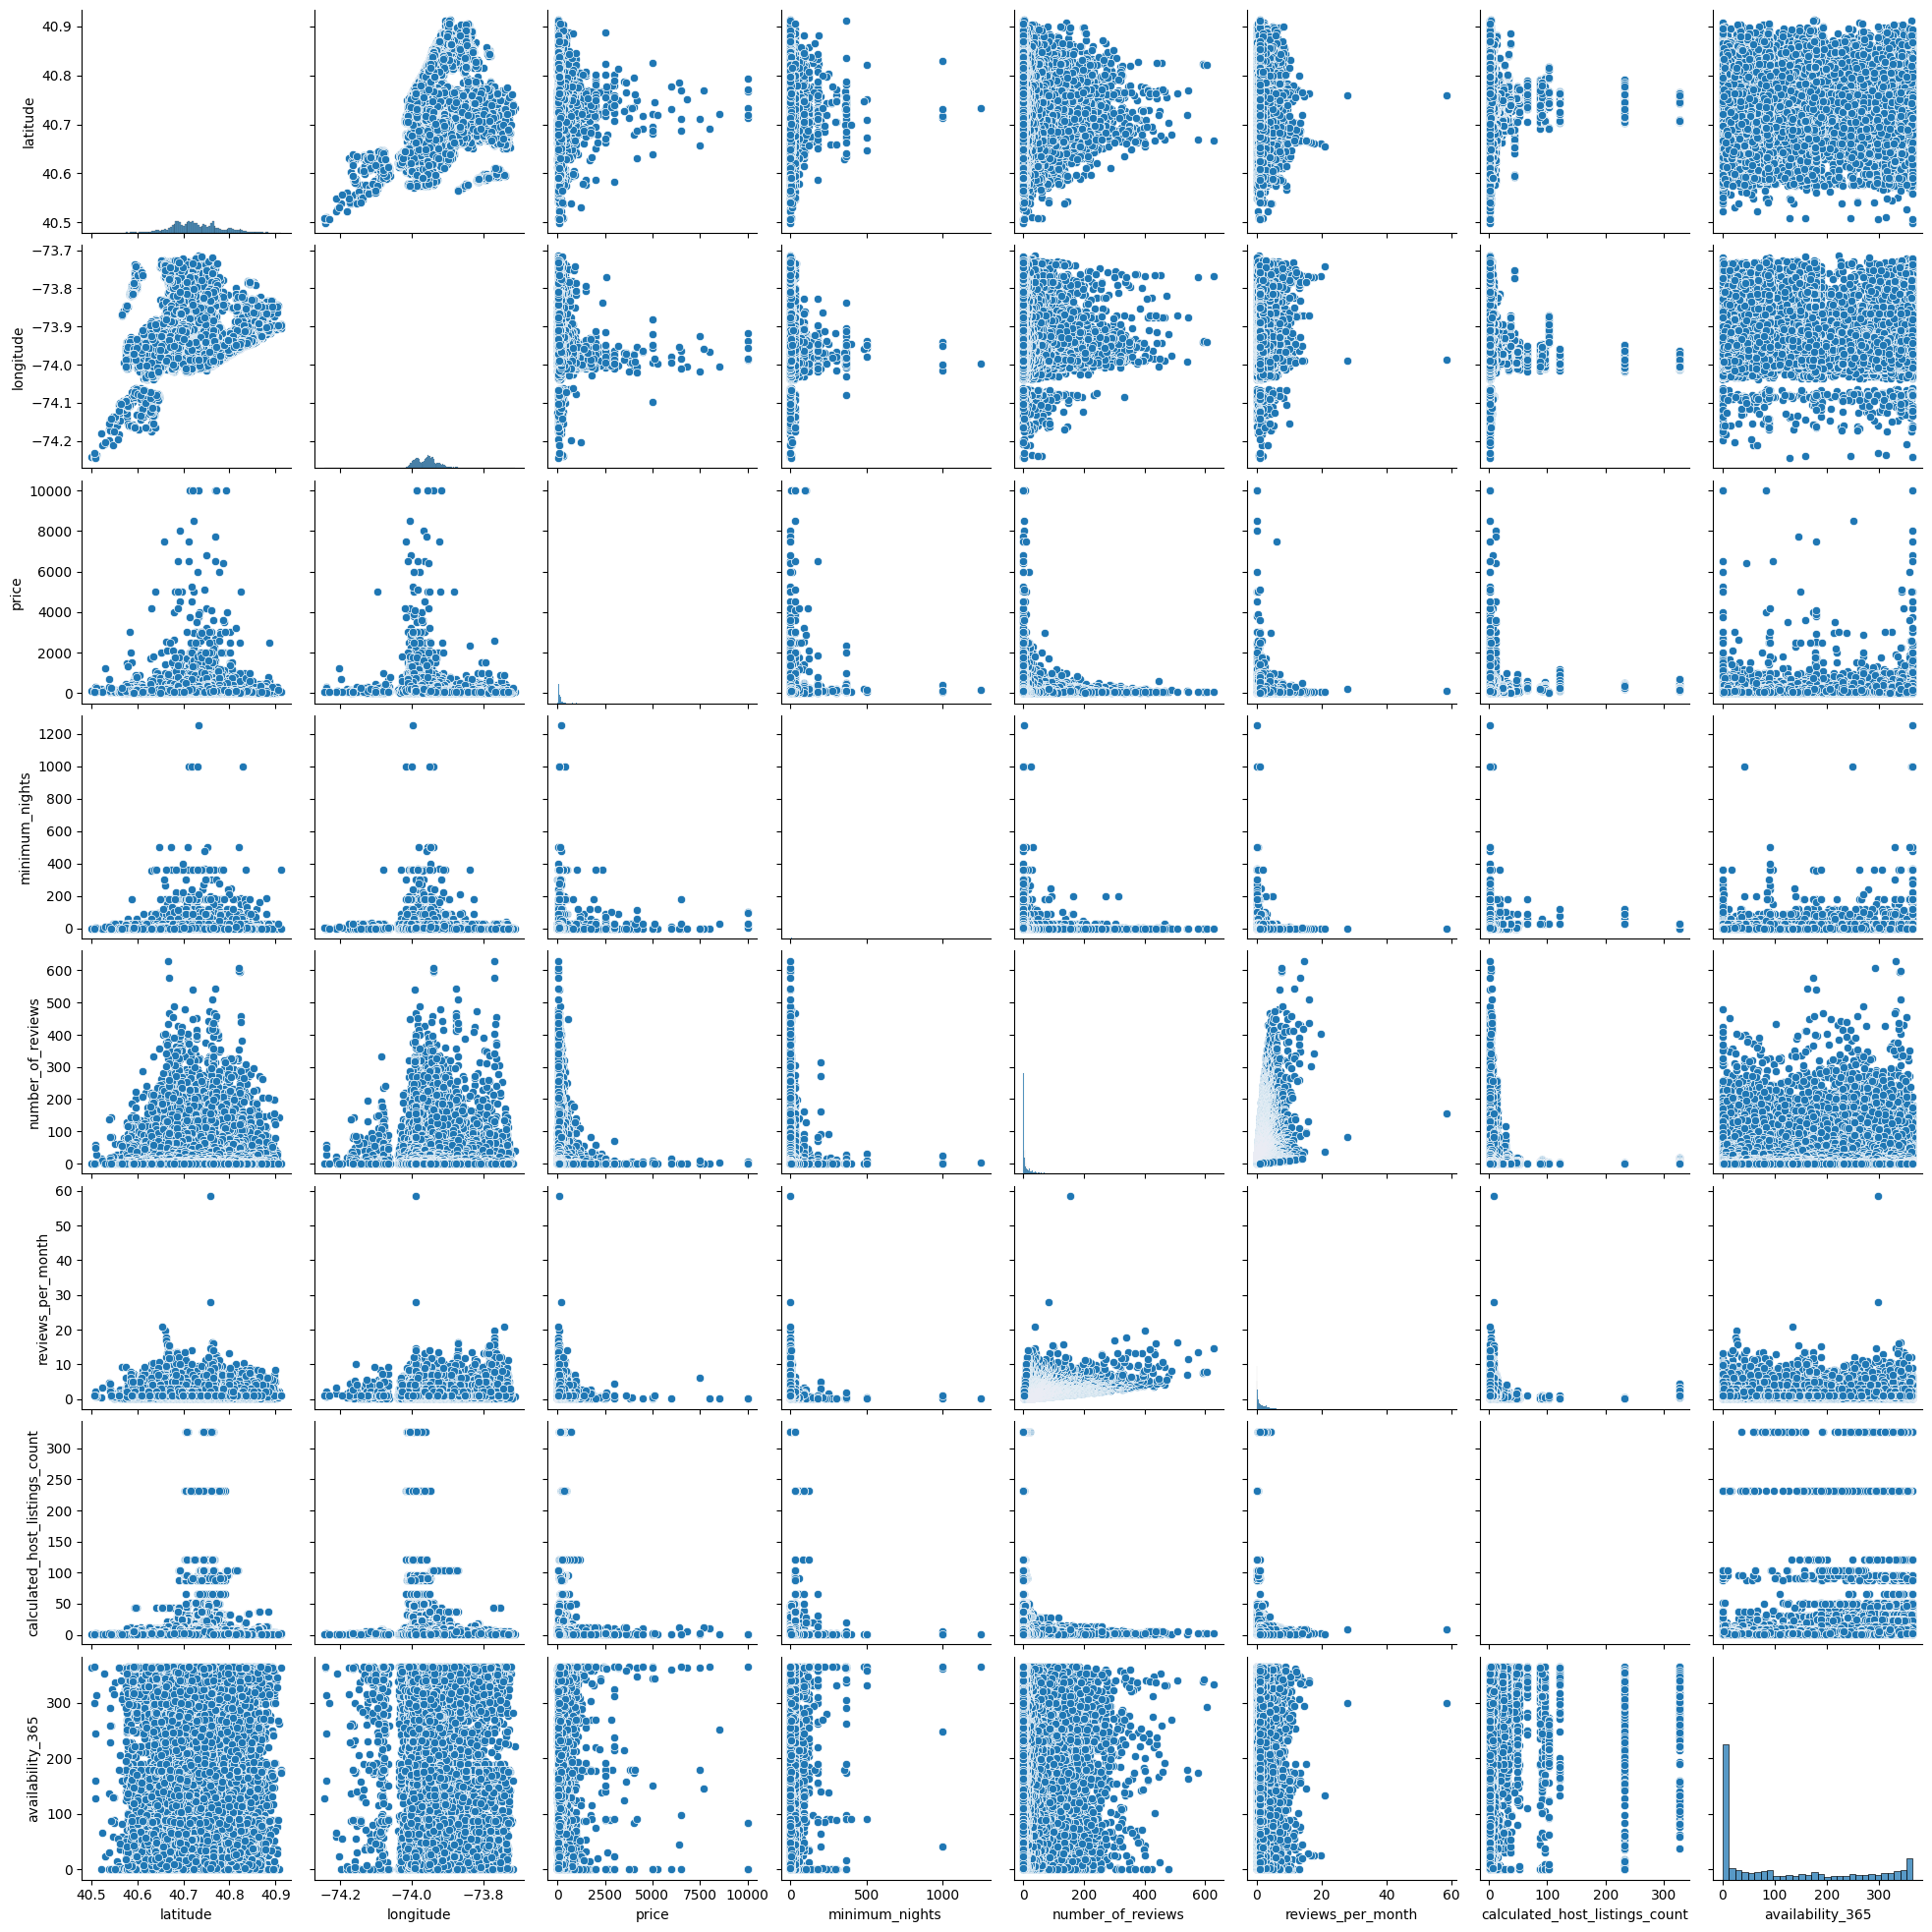

In [19]:
sns.pairplot(data = total_data)

## 5. Ingeniería de características


In [20]:
total_data.describe()

,latitude,longitude,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365
count,48895.000000,48895.000000,48895.000000,48895.000000,48895.000000,38843.000000,48895.000000,48895.000000
mean,40.728949,-73.952170,152.720687,7.029962,23.274466,1.373221,7.143982,112.781327
std,0.054530,0.046157,240.154170,20.510550,44.550582,1.680442,32.952519,131.622289
min,40.499790,-74.244420,0.000000,1.000000,0.000000,0.010000,1.000000,0.000000
25%,40.690100,-73.983070,69.000000,1.000000,1.000000,0.190000,1.000000,0.000000
50%,40.723070,-73.955680,106.000000,3.000000,5.000000,0.720000,1.000000,45.000000
75%,40.763115,-73.936275,175.000000,5.000000,24.000000,2.020000,2.000000,227.000000
max,40.913060,-73.712990,10000.000000,1250.000000,629.000000,58.500000,327.000000,365.000000


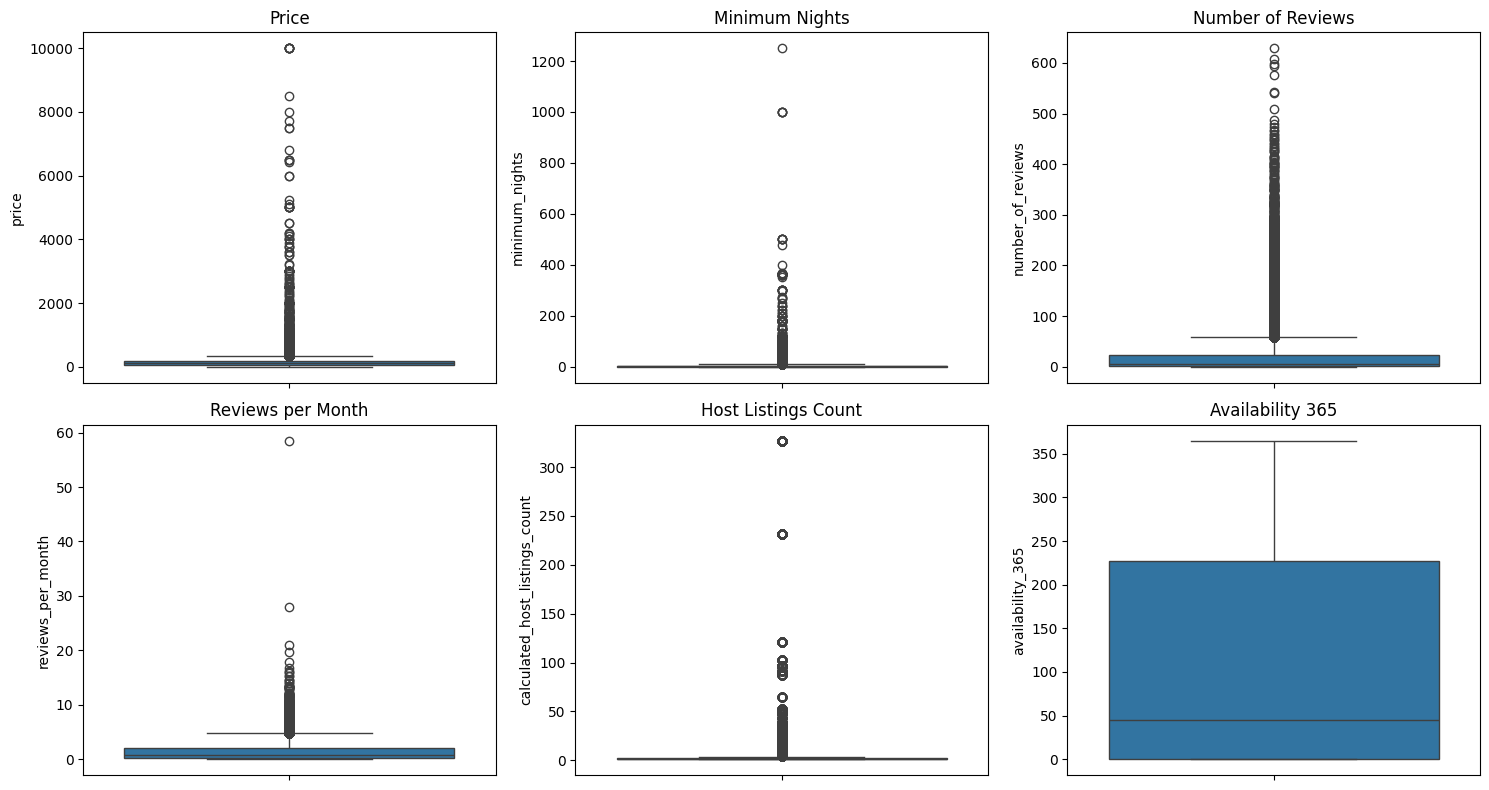

In [22]:
#para graficar outliers

fig, axis = plt.subplots(2, 3, figsize=(15, 8))

# Boxplots para detectar outliers visualmente
sns.boxplot(ax=axis[0, 0], data=total_data, y="price")
axis[0, 0].set_title("Price")

sns.boxplot(ax=axis[0, 1], data=total_data, y="minimum_nights")
axis[0, 1].set_title("Minimum Nights")

sns.boxplot(ax=axis[0, 2], data=total_data, y="number_of_reviews")
axis[0, 2].set_title("Number of Reviews")

sns.boxplot(ax=axis[1, 0], data=total_data, y="reviews_per_month")
axis[1, 0].set_title("Reviews per Month")

sns.boxplot(ax=axis[1, 1], data=total_data, y="calculated_host_listings_count")
axis[1, 1].set_title("Host Listings Count")

sns.boxplot(ax=axis[1, 2], data=total_data, y="availability_365")
axis[1, 2].set_title("Availability 365")

plt.tight_layout()
plt.show()

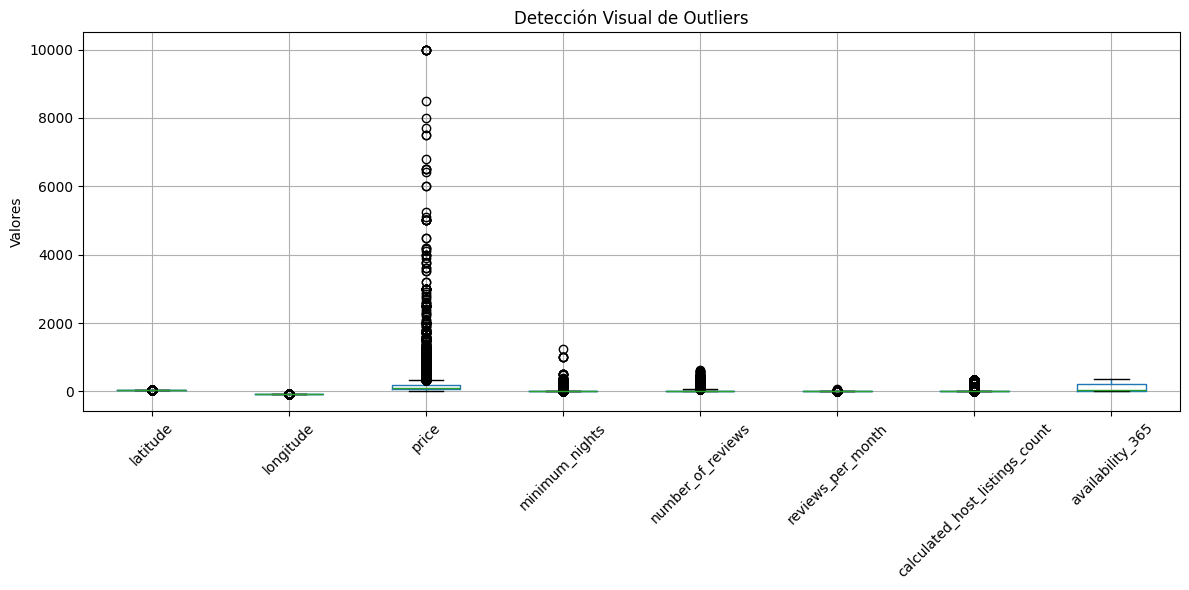

In [23]:

# Seleccionar variables numéricas
nums = total_data.select_dtypes(include=['number'])

# Crear boxplots
nums.boxplot(figsize=(12, 6), rot=45)
plt.title('Detección Visual de Outliers')
plt.ylabel('Valores')
plt.tight_layout()
plt.show()

In [24]:
price_stats = total_data["price"].describe()
price_stats

count    48895.000000
mean       152.720687
std        240.154170
min          0.000000
25%         69.000000
50%        106.000000
75%        175.000000
max      10000.000000
Name: price, dtype: float64

In [25]:
price_iqr = price_stats["75%"] - price_stats["25%"]
upper_limit = price_stats["75%"] + 1.5 * price_iqr
lower_limit = price_stats["25%"] - 1.5 * price_iqr

print(f"Los límites superior e inferior para la búsqueda de outliers son {round(upper_limit, 2)} y {round(lower_limit, 2)}, con un rango intercuartílico de {round(price_iqr, 2)}")

Los límites superior e inferior para la búsqueda de outliers son 334.0 y -90.0, con un rango intercuartílico de 106.0


In [26]:
#cantidad de outliers
outliers_altos = total_data[total_data['price'] > upper_limit]
outliers_bajos = total_data[total_data['price'] < lower_limit]

print(f"Outliers altos: {len(outliers_altos)}")
print(f"Outliers bajos: {len(outliers_bajos)}")

Outliers altos: 2972
Outliers bajos: 0


Basándonos en estos resultados, deberíamos eliminar los registros de los precios cuyo valor supere los 333. Sin embargo, nuestro criterio es muy importante aquí y, según los precios que vimos en el diagrama de caja, los valores más extremos están por encima de 200. Veamos cuántos valores representan ese valor extremo de 10000:

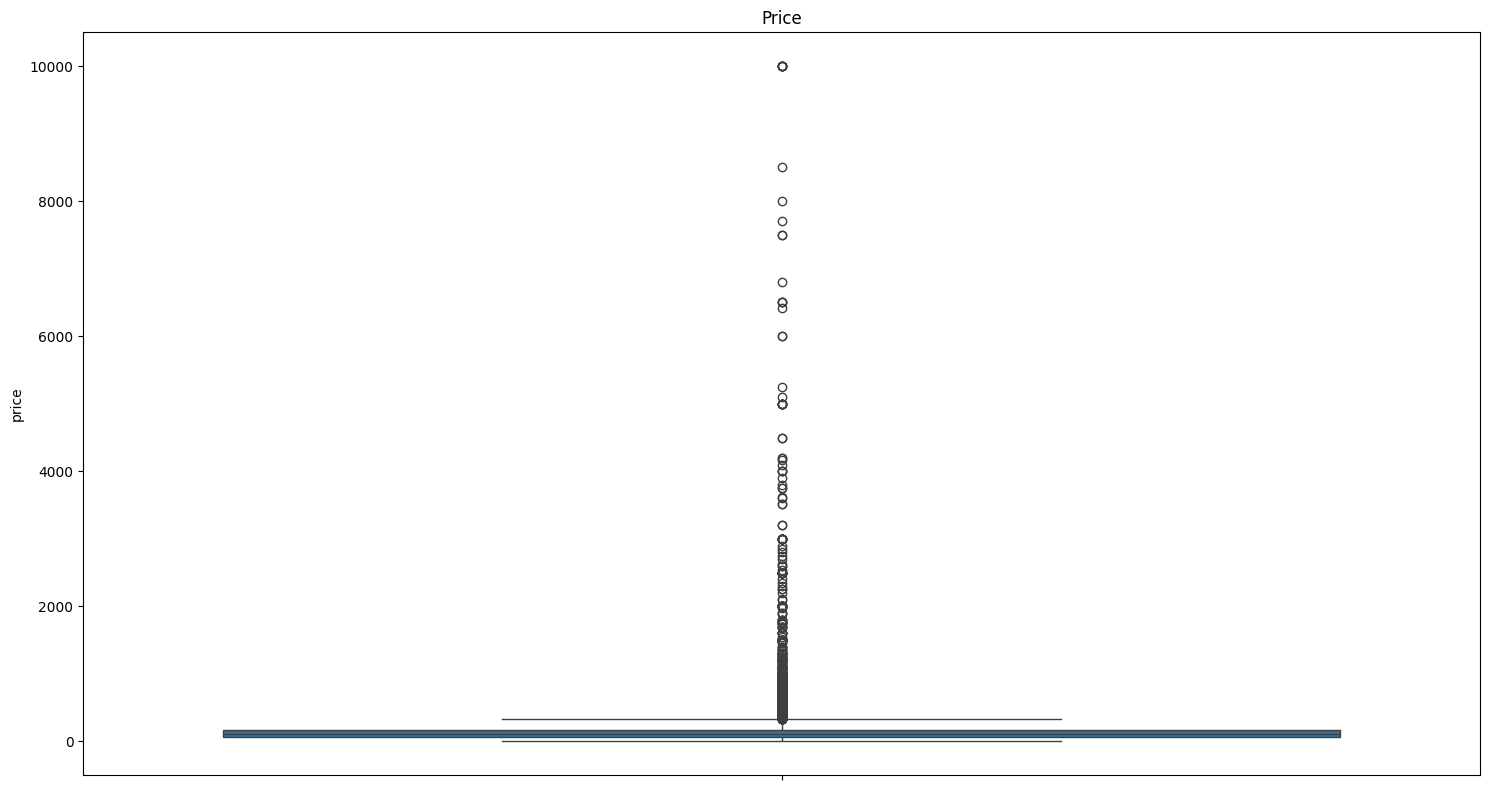

In [33]:
fig, axis = plt.subplots(1,1, figsize=(15, 8))
sns.boxplot(ax=axis, data=total_data, y="price")
axis.set_title("Price")

plt.tight_layout()
plt.show()


In [40]:
total_data[total_data["price"] > 335]

,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365,price_category
61,Manhattan,Chelsea,40.74623,-73.99530,Entire home/apt,375,180,5,0.12,1,180,Premium
85,Brooklyn,Brooklyn Heights,40.69723,-73.99268,Entire home/apt,800,1,25,0.24,1,7,Premium
103,Manhattan,West Village,40.73096,-74.00319,Entire home/apt,500,4,46,0.55,2,243,Premium
114,Manhattan,East Village,40.72540,-73.98157,Entire home/apt,350,2,7,0.06,4,298,Premium
121,Brooklyn,South Slope,40.66499,-73.97925,Entire home/apt,400,2,16,0.24,2,216,Premium
...,...,...,...,...,...,...,...,...,...,...,...,...
48758,Queens,Long Island City,40.75508,-73.93258,Entire home/apt,350,2,0,NaN,1,364,Premium
48833,Manhattan,Financial District,40.70605,-74.01042,Entire home/apt,475,2,0,NaN,1,64,Premium
48839,Brooklyn,Sheepshead Bay,40.59866,-73.95661,Private room,800,1,0,NaN,1,23,Premium
48842,Manhattan,Chelsea,40.75204,-74.00292,Entire home/apt,350,1,0,NaN,1,9,Premium


Se identificaron 2964 propiedades con precios superiores a 335.

outliers:

- la Mayoría de las propiedades son de tipo Entire home/apt.
- precio elevado en muchas propiedades.

## 6. Análisis de valores faltantes

In [43]:
total_data.isnull().sum().sort_values(ascending=False)

reviews_per_month                 10052
price_category                       11
neighbourhood_group                   0
neighbourhood                         0
longitude                             0
latitude                              0
room_type                             0
price                                 0
number_of_reviews                     0
minimum_nights                        0
calculated_host_listings_count        0
availability_365                      0
dtype: int64

dividir ese resultado por la longitud de nuestro DataFrame (número de filas) para obtener el porcentaje de valores faltantes en cada columna

In [44]:
total_data.isnull().sum().sort_values(ascending=False) / len(total_data)

reviews_per_month                 0.205583
price_category                    0.000225
neighbourhood_group               0.000000
neighbourhood                     0.000000
longitude                         0.000000
latitude                          0.000000
room_type                         0.000000
price                             0.000000
number_of_reviews                 0.000000
minimum_nights                    0.000000
calculated_host_listings_count    0.000000
availability_365                  0.000000
dtype: float64

Para los casos con datos faltantes observados en las variables reviews_per_month, y price_category, vamos a utilizar la imputación numérica a través de la función fillna(). En este caso vamos a utilizar algunas de las distintas opciones que se pueden escoger para rellenar valores:

In [47]:
total_data["reviews_per_month"] = total_data["reviews_per_month"].fillna(total_data["reviews_per_month"].median()) # numerica
total_data["price_category"] = total_data["price_category"].fillna(total_data["price_category"].mode()[0]) #categorica


total_data.isnull().sum()

neighbourhood_group               0
neighbourhood                     0
latitude                          0
longitude                         0
room_type                         0
price                             0
minimum_nights                    0
number_of_reviews                 0
reviews_per_month                 0
calculated_host_listings_count    0
availability_365                  0
price_category                    0
dtype: int64

### 5.1 Inferencia de nuevas características

In [53]:
total_data["host_type"] = pd.cut(
    total_data["calculated_host_listings_count"],
    bins=[0, 1, 5, 20, np.inf],
    labels=["Casual", "Pequeño", "Mediano", "Profesional"]
)

total_data.head()

,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365,price_category,host_type
0,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,0.21,6,365,Alto,Mediano
1,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,0.38,2,355,Premium,Pequeño
2,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,0.72,1,365,Alto,Casual
3,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,4.64,1,194,Medio,Casual
4,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,0.10,1,0,Medio,Casual


### 5.2 Escalado de valores

In [55]:


num_variables = ["latitude", "longitude", "minimum_nights", "number_of_reviews", "reviews_per_month", "calculated_host_listings_count", "availability_365",]
X = total_data[num_variables]

# Normalización
scaler_norm = StandardScaler()
X_norm = pd.DataFrame(scaler_norm.fit_transform(X), index=total_data.index, columns=num_variables)

# Min-Max
scaler_minmax = MinMaxScaler()
X_minmax = pd.DataFrame(scaler_minmax.fit_transform(X), index=total_data.index, columns=num_variables)

X_norm.head(), X_minmax.head()

(   latitude  longitude  minimum_nights  number_of_reviews  reviews_per_month  \
 0 -1.493849  -0.437652       -0.293996          -0.320414          -0.676551   
 1  0.452436  -0.684639       -0.293996           0.487665          -0.564771   
 2  1.468399   0.222497       -0.196484          -0.522433          -0.341211   
 3 -0.803398  -0.164450       -0.293996           5.538156           2.236302   
 4  1.275660   0.177216        0.144807          -0.320414          -0.748879   
 
    calculated_host_listings_count  availability_365  
 0                       -0.034716          1.916250  
 1                       -0.156104          1.840275  
 2                       -0.186451          1.916250  
 3                       -0.186451          0.617065  
 4                       -0.186451         -0.856865  ,
    latitude  longitude  minimum_nights  number_of_reviews  reviews_per_month  \
 0  0.357393   0.511921        0.000000           0.014308           0.003419   
 1  0.614199   0.49

A continuación detallaremos cómo podemos aplicar cada una de ellas, pero recordemos que depende mucho del modelo que vayamos a querer entrenar:

### 5.3 Normalización

In [57]:
num_variables = ["latitude", "longitude", "minimum_nights", "number_of_reviews", "reviews_per_month", "calculated_host_listings_count", "availability_365",]
X = total_data[num_variables]

# Normalización (media 0, desviación estándar 1)
scaler_norm = StandardScaler()
X_norm = pd.DataFrame(scaler_norm.fit_transform(X), index=total_data.index, columns=num_variables)

# Escalado Min-Max (valores entre 0 y 1)
scaler_minmax = MinMaxScaler()
X_minmax = pd.DataFrame(scaler_minmax.fit_transform(X), index=total_data.index, columns=num_variables)

X_norm.head(), X_minmax.head()

(   latitude  longitude  minimum_nights  number_of_reviews  reviews_per_month  \
 0 -1.493849  -0.437652       -0.293996          -0.320414          -0.676551   
 1  0.452436  -0.684639       -0.293996           0.487665          -0.564771   
 2  1.468399   0.222497       -0.196484          -0.522433          -0.341211   
 3 -0.803398  -0.164450       -0.293996           5.538156           2.236302   
 4  1.275660   0.177216        0.144807          -0.320414          -0.748879   
 
    calculated_host_listings_count  availability_365  
 0                       -0.034716          1.916250  
 1                       -0.156104          1.840275  
 2                       -0.186451          1.916250  
 3                       -0.186451          0.617065  
 4                       -0.186451         -0.856865  ,
    latitude  longitude  minimum_nights  number_of_reviews  reviews_per_month  \
 0  0.357393   0.511921        0.000000           0.014308           0.003419   
 1  0.614199   0.49

### 5.4 Escalado Mínimo-Máximo.

In [58]:

num_variables = ["latitude", "longitude", "minimum_nights", "number_of_reviews", "reviews_per_month", "calculated_host_listings_count", "availability_365",]
X = total_data[num_variables]

scaler = MinMaxScaler()
X_minmax = pd.DataFrame(scaler.fit_transform(X), index=total_data.index, columns=num_variables)

X_minmax.head()

,latitude,longitude,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365
0,0.357393,0.511921,0.000000,0.014308,0.003419,0.015337,1.000000
1,0.614199,0.490469,0.000000,0.071542,0.006326,0.003067,0.972603
2,0.748252,0.569257,0.001601,0.000000,0.012139,0.000000,1.000000
3,0.448496,0.535649,0.000000,0.429253,0.079159,0.000000,0.531507
4,0.722820,0.565324,0.007206,0.014308,0.001539,0.000000,0.000000


## 6 Selección de características

 análisis exploratorio:

* Simplificar el modelo para que sea más fácil de entender e interpretar.
* Reducir el tiempo de entrenamiento del modelo.
* Evitar el sobre ajuste al reducir la dimensionalidad del modelo y minimizar el ruido y las correlaciones innecesarias.
* Mejorar el rendimiento del modelo al eliminar las características irrelevantes.

La librería sklearn contiene gran parte de las mejores alternativas para llevarla a cabo. Una de las herramientas que más se utilizan para realizar procesos de selección de características rápidos y con buenos resultados es SelectKBest. Esta función selecciona las k mejores características de nuestro conjunto de datos basándose en una función de un test estadístico. Este test estadístico normalmente es un ANOVA o un Chi-Cuadrado:

In [ ]:
num_variables = [
    "latitude", "longitude", "minimum_nights", "number_of_reviews", 
    "reviews_per_month", "calculated_host_listings_count", "availability_365"
]

X = total_data[num_variables].apply(pd.to_numeric, errors="coerce")
y = total_data["price"]

#hay que tener en cuenta si es regresion o clasificacion !!!!!!!

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42  #
)

# Pipeline con f_regression para regresión
pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("selector", SelectKBest(score_func=f_regression, k=5))  # ← regresion o clasificacion en las librerias
])

# Fit y transform
X_train_sel = pipe.fit_transform(X_train, y_train)
mask = pipe.named_steps["selector"].get_support()
selected_cols = np.array(num_variables)[mask]

X_test_sel = pipe.transform(X_test)

# Convertir a DataFrame
X_train_sel = pd.DataFrame(X_train_sel, index=X_train.index, columns=selected_cols)
X_test_sel = pd.DataFrame(X_test_sel, index=X_test.index, columns=selected_cols)


print("Features seleccionadas:", list(selected_cols))
X_train_sel.head()

Features seleccionadas: [np.str_('longitude'), np.str_('minimum_nights'), np.str_('number_of_reviews'), np.str_('calculated_host_listings_count'), np.str_('availability_365')]


,longitude,minimum_nights,number_of_reviews,calculated_host_listings_count,availability_365
32645,-73.95530,3.0,11.0,1.0,1.0
23615,-73.94048,2.0,2.0,1.0,0.0
31183,-73.95947,2.0,0.0,2.0,0.0
29260,-73.93118,3.0,87.0,1.0,267.0
7275,-73.89564,5.0,13.0,1.0,0.0


In [68]:
X_test_sel.head()

,longitude,minimum_nights,number_of_reviews,calculated_host_listings_count,availability_365
879,-73.97777,3.0,62.0,1.0,189.0
44383,-73.90779,21.0,0.0,1.0,73.0
15394,-73.99016,2.0,17.0,1.0,0.0
43230,-74.01050,2.0,5.0,327.0,272.0
16332,-73.93287,2.0,30.0,1.0,30.0


In [69]:
X_train_sel["price"] = list(y_train)
X_test_sel["price"] = list(y_test)

In [72]:
X_train_sel.to_csv("clean_airbnb_train.csv", index=False)
X_test_sel.to_csv("clean_airbnb_test.csv", index=False)

print("Archivos guardados correctamente:")
print("   - clean_airbnb_train.csv")
print("   - clean_airbnb_test.csv")


Archivos guardados correctamente:
   - clean_airbnb_train.csv
   - clean_airbnb_test.csv
